# <b>Bayesian Optimisation of an LSTM Model</b>

### <b>1 | Import Libraries</b>

In [ ]:
### Maths and Data-Handling
import numpy as np
#from copy import deepcopy
import pandas as pd
from pysmilesutils.tokenize import *

### Timing
import timeit

### Visualisation
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw

### Scikit
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from skopt import gp_minimize
from skopt.plots import plot_convergence

### PyTorch
import torch
from torch import nn   

In [2]:
WEB_COLOR = "#085E57"     ### core colour from my personal webpage, defined for convenience

### <b>2 | Data Wrangling</b>

#### 2a | Import data and Tokenise

In [3]:
# load dataset as pandas.DataFrame object
logPdata = pd.read_csv('logP_dataset.csv', names=['SMILES', 'ClogP'])

print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)

log(P) DataFrame columns:  Index(['SMILES', 'ClogP'], dtype='object')
log(P) DataFrame shape:  (14610, 2)


In [4]:
# tokenize SMILES strings
smiles_list = logPdata['SMILES'].to_list()
tokenizer = SMILESTokenizer(smiles=smiles_list)


# add to dataframe
logPdata['Tokenize'] = tokenizer(smiles_list)

print("Tokenizer vocabulary dictionary:", tokenizer.vocabulary)
print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)

Tokenizer vocabulary dictionary: {' ': 0, '^': 1, '&': 2, '?': 3, 'C': 4, '[': 5, '@': 6, 'H': 7, ']': 8, '(': 9, ')': 10, 'l': 11, '=': 12, 'B': 13, 'r': 14, 'N': 15, 'O': 16, '1': 17, '3': 18, '2': 19, 'P': 20, 'F': 21, 'I': 22, '+': 23, 'S': 24, '-': 25, '/': 26, '\\': 27, '.': 28, '8': 29, '#': 30, '4': 31, '9': 32, '5': 33, '7': 34, '0': 35, '6': 36}
log(P) DataFrame columns:  Index(['SMILES', 'ClogP', 'Tokenize'], dtype='object')
log(P) DataFrame shape:  (14610, 3)


In [5]:
# check length of each tokenized SMILES string
# store in 'tokens_len' list
tokens_len = list()

for tokens in logPdata['Tokenize']:
    entry_length = tokens.size()[0]
    tokens_len.append(entry_length)


# add to dataframe
logPdata['Tokenized Length'] = tokens_len

print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)
print('Maximum Token Length: ', max(tokens_len))

log(P) DataFrame columns:  Index(['SMILES', 'ClogP', 'Tokenize', 'Tokenized Length'], dtype='object')
log(P) DataFrame shape:  (14610, 4)
Maximum Token Length:  140


#### 2b | Filter SMILES length

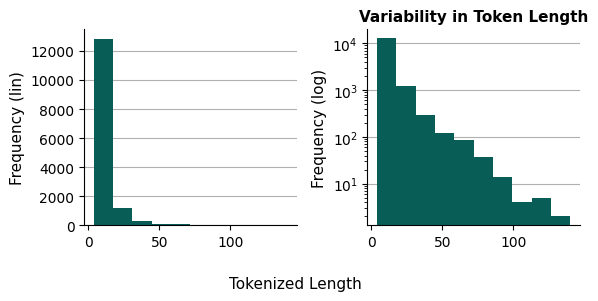

In [6]:
# display histogram of the frequency of tokenized length
fig, ax = plt.subplots(1, 2, figsize=(6,3))

### chart scaling
ax[1].set_yscale('log')

### gridlines
ax[0].spines[['right','top']].set_visible(False)
ax[0].grid(which='major', axis='y', zorder=1)
ax[1].spines[['right','top']].set_visible(False)
ax[1].grid(which='major', axis='y', zorder=1)

### data
ax[0].hist(tokens_len, label='Tokenized SMILEs Length', color=WEB_COLOR, zorder=2)
ax[1].hist(tokens_len, label='Tokenized SMILEs Length', color=WEB_COLOR, zorder=2)

### chart labels
plt.title(
    f'Variability in Token Length', 
    fontweight='bold', fontsize=11
)
fig.supxlabel('Tokenized Length', fontsize=11)
ax[0].set_ylabel('Frequency (lin)', fontsize=11)
ax[1].set_ylabel('Frequency (log)', fontsize=11)


fig.tight_layout()
plt.show()

In [7]:
# filter dataframe by token length
# data is too sparse above this limit to provide sufficient quality for the model 
FILTER_TO_LENGTH = 20
logPdata_filtered = logPdata[logPdata['Tokenized Length'] < FILTER_TO_LENGTH]

print('log(P) DataFrame shape after filtering: ', logPdata_filtered.shape)

log(P) DataFrame shape after filtering:  (13288, 4)


#### 2c | Train-test split

In [8]:
# split into training and testing datasets
split_data = train_test_split(
    logPdata_filtered, test_size=0.1, shuffle=True
    )

train, test = split_data[0], split_data[1]

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)

Training data shape:  (11959, 4)
Testing data shape:  (1329, 4)


#### 2d | Convert to standardised PyTorch tensor objects

In [9]:
def format_descriptors(data:pd.DataFrame, max_token_len:int):
    '''
    Formats SMILES strings to convert them into a padded PyTorch tensor object of set length.
    '''
    # create blank numpy.array object of correct size
    X = np.zeros((len(data), max_token_len))

    # overwrite blank numpy.array with tokenised data
    # ensures length of all entries is standardised by padding with '0' values
    for i, token in zip(np.arange(0,len(data),1), data['Tokenize']):
        token_arr = np.asarray(token)
        X[i][:len(token_arr)] = token_arr

    # convert to torch.tensor object
    X = torch.tensor(X[:, :, None], dtype = torch.float32)

    print('Shape of Descriptor Data: ', X.shape)

    return X


def format_labels(data:pd.DataFrame):
    '''
    Converts Clog(P) data to a PyTorch tensor object.
    '''
    # convert Clog(P) data to a torch.tensor object
    Y = np.asarray(data['ClogP'])
    Y = torch.tensor(Y[:, None], dtype=torch.float32)

    print('Shape of True Value Data: ', Y.shape)

    return Y

In [10]:
# format training and testing data
trainX = format_descriptors(train, FILTER_TO_LENGTH)   ### training data descriptors
testX = format_descriptors(test, FILTER_TO_LENGTH)     ### testing data descriptors

trainY_true = format_labels(train)                     ### training data true Clog(P) values
testY_true = format_labels(test)                       ### testing data true Clog(P) values

Shape of Descriptor Data:  torch.Size([11959, 20, 1])
Shape of Descriptor Data:  torch.Size([1329, 20, 1])
Shape of True Value Data:  torch.Size([11959, 1])
Shape of True Value Data:  torch.Size([1329, 1])


### <b>3 | LSTM Model Architecture and Experiment Procedure</b>

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout_rate=0.0):
        '''
        Define LSTM model architecture
        '''
        # ???
        super(LSTMModel, self).__init__()

        # define internal variables
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        # LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)

        # Dropout layer, mitigates overfitting by dropping some neurons during training 
                # to encourage the model to learn redundant representations
        self.dropout = nn.Dropout(dropout_rate)

        # Linear layer, reformats LSTM output to the desired dimensionality
        self.fc = nn.Linear(hidden_dim, output_dim)


    def forward(self, x, h0=None, c0=None):
        '''
        Run LSTM model
        '''
        # ???
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        # ???
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out, hn, cn

In [12]:
def run_experiment(
        #train, trainX, trainY_true, 
        #test, testX, testY_true, 
        hidden_dim, learning_rate, num_epochs, layer_dim=1, dropout_rate=0.0
    ):
    '''
    Runs one complete training and evaluation of an LSTM model.
    
    (1) Model, optimiser, and loss criterion are defined
    (2) Model is trained
    (3) Model is evaluated with training data and predicted values stored
    (4) Model is evaluated with test data and predicted values stored
    (5) Post-processing to output results in a usable format

    '''
    ##############################################
    #----------------DEFINE MODEL----------------#
    ##############################################

    # instantiate model, optimizer, and loss criterion
    model = LSTMModel(
        input_dim=1, 
        hidden_dim=hidden_dim, 
        layer_dim=layer_dim, 
        output_dim=1,
        dropout_rate=dropout_rate
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    

    ##############################################
    #----------------TRAIN MODEL-----------------#
    ##############################################

    # set initial hidden state, h0 and cell state, c0
    h0, c0 = None, None

    # blank list to store loss values 
    loss_by_epoch = list()

    # iterate training for set number of epochs
    for epoch in range(num_epochs):

        model.train()                   # switch to model training mode
        optimizer.zero_grad()           # reset gradients to zero for next training iteration

        outputs, h0, c0 = model(trainX, h0, c0)     # train model and update h0, c0

        loss = criterion(outputs, trainY_true)      # calculate loss
        
        loss.backward()                             # backpropagation
                                                        # compute gradients of the loss

        optimizer.step()                            # optimisation
                                                        # adjust parameters based on gradients 
                                                        # with aim of minimising the loss
        
        h0, c0 = h0.detach(), c0.detach()           # detach h0 and c0 from gradients
        
        # add loss value to storage list
        loss_by_epoch.append(loss.item())

        # print every 10th loss value during model training
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


    ##############################################
    #---------EVALUTE WITH TRAINING DATA---------#
    ##############################################

    # switch to model evaluation mode
    model.eval()

    # evaluate model and detach tensor
    trainY_pred, _, _ = model(trainX, h0, c0)
    trainY_pred_arr = trainY_pred.detach().numpy()

    # calculate errors as predicted values minus true values and detach tensor
    train_error = trainY_pred-trainY_true
    train_error = train_error.detach().numpy()


    ##############################################
    #-----------EVALUTE WITH TEST DATA-----------#
    ##############################################

    # switch to model evaluation mode
    model.eval()

    # evaluate model and detach tensor
    testY_pred, _, _ = model(testX, None, None)
    testY_pred_arr = testY_pred.detach().numpy()

    # calculate individual errors as predicted values minus true values and detach tensor
    test_error = testY_pred-testY_true
    test_error = test_error.detach().numpy()


    ##############################################
    #--------------POST-PROCESSING---------------#
    ##############################################

    # add predicted values to log(P) DataFrame for training and test data
    # add individal error values to same DataFrame
    train['ClogP (Predicted)'] = trainY_pred_arr
    train['Error'] = train_error

    test['ClogP (Predicted)'] = testY_pred_arr
    test['Error'] = test_error

    # calculate root mean square error for training and test datasets
    rmse_train = np.sqrt(
        mean_squared_error(train['ClogP'], train['ClogP (Predicted)'])
    )

    rmse_test = np.sqrt(
        mean_squared_error(test['ClogP'], test['ClogP (Predicted)'])
    )

    # print RMSE values
    print(f'Training RMSE: {rmse_train:.5f}')
    print(f'Testing RMSE: {rmse_test:.5f}')


    return model, rmse_train, rmse_test, loss_by_epoch

### <b>4 | Run Single User-Defined Experiment</b>

In [13]:
# define variables
HIDDEN_DIM = 100
LEARNING_RATE = 0.01
NUM_EPOCHS = 30
NUM_LAYERS = 1
DROPOUT_RATE = 0.0

# run experiment
_, rmse_train, rmse_test, _ = run_experiment(
    #train, trainX, trainY_true, test, testX, testY_true,
    HIDDEN_DIM, LEARNING_RATE, NUM_EPOCHS, NUM_LAYERS, DROPOUT_RATE
)

Epoch [10/30], Loss: 1.8420
Epoch [20/30], Loss: 1.5884
Epoch [30/30], Loss: 1.5820
Training RMSE: 1.25667
Testing RMSE: 1.26029


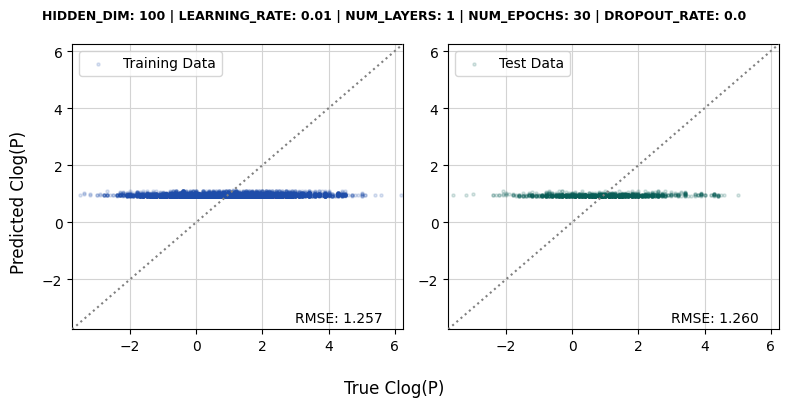

In [14]:
##############################################
#---------------VISUALISATION----------------#
##############################################

# plot true vs. predicted log(P) values for training and testing data 
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].grid(True, color='lightgrey', zorder=1)
ax[1].grid(True, color='lightgrey', zorder=1)

### data
ax[0].scatter(train['ClogP'], train['ClogP (Predicted)'], c='#1E4DAA', s=5, alpha=0.15, label='Training Data', zorder=2)
ax[1].scatter(test['ClogP'], test['ClogP (Predicted)'], c=WEB_COLOR, s=5, alpha=0.15, label='Test Data', zorder=2)

### ideal fit
ax[0].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":", zorder=3)
ax[1].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":", zorder=3)

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[0].set_ylim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)
ax[1].set_ylim(-3.75, 6.25)

### legends
ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)

### chart labels
fig.supxlabel('True Clog(P)')
fig.supylabel('Predicted Clog(P)')
fig.suptitle(
    f'HIDDEN_DIM: {HIDDEN_DIM} | LEARNING_RATE: {LEARNING_RATE} | NUM_LAYERS: {NUM_LAYERS} | NUM_EPOCHS: {NUM_EPOCHS} | DROPOUT_RATE: {DROPOUT_RATE}', 
    fontsize=9, fontweight='bold', 
)

### annotate with RMSEs
ax[0].annotate(f'RMSE: {rmse_train:.3f}', xy=(3,-3.5), fontsize=10)
ax[1].annotate(f'RMSE: {rmse_test:.3f}', xy=(3,-3.5), fontsize=10)

fig.tight_layout()
plt.show()

### <b>5 | Testing Comparison Score for Predicted and True Values</b>

In [15]:
# mock up values equivalent to the RMSE of the training and test datasets
xs = np.linspace(0,1.5,20)
ys = np.linspace(0,1.5,20)

# blank lists to store data for plotting
x_list, y_list = list(), list()
size_list = list()
variance_list = list()
score_list = list()

# user-defined weighting factor
BETA = 1.1

# iterate through each combination of x and y
for x in xs:
    for y in ys:
        size = (x + y)/2            # calculate average value of x and y
        variance = abs(x-y)         # calculate absolute difference between x and y

        # add to storage lists
        x_list.append(x)
        y_list.append(y)
        size_list.append(size)
        variance_list.append(variance)

        #calculate score and add to storage list
        score_list.append(size+(BETA*variance))

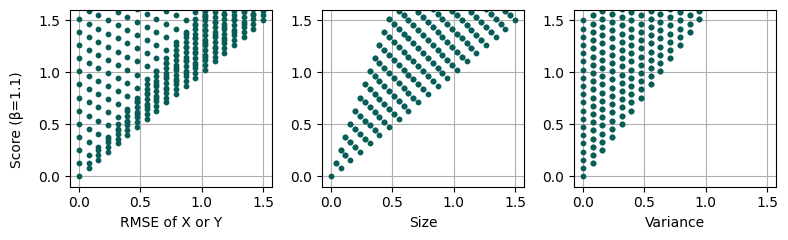

In [16]:
# plot toy data for combination score
fig, ax = plt.subplots(1, 3, figsize=(8,2.5))

# plot one variable's RMSE against combined score to show all possible scores
ax[0].grid(visible=True, zorder=1)
ax[0].scatter(x_list, score_list, s=10, c=WEB_COLOR, zorder=2)
ax[0].set_xlabel('RMSE of X or Y', fontsize=10)

# plot average size of RMSE against combined score to show all possible scores
ax[1].grid(visible=True, zorder=1)
ax[1].scatter(size_list, score_list, s=10, c=WEB_COLOR, zorder=2)
ax[1].set_xlabel('Size', fontsize=10)

# plot variation in RMSE against combined score to show all possible scores
ax[2].grid(visible=True, zorder=1)
ax[2].scatter(variance_list, score_list, s=10, c=WEB_COLOR, zorder=2)
ax[2].set_xlabel('Variance', fontsize=10)

fig.supylabel(f'Score (β={BETA})', fontsize=10)

# NOTE: that all combined score axes are set to a maximum of 1.5
# this is because 1.5 has been chosen as a maximum RMSE value for the variables, X Y
# plotting values above this reveals artefacts in the spread of data shown here
ax[0].set_ylim(-0.1,1.6)
ax[1].set_ylim(-0.1,1.6)
ax[2].set_ylim(-0.1,1.6)

fig.tight_layout()
plt.show()

### <b>6 | Bayesian Optimisation of Hyperparameters</b>

#### 6a | Define Scoring Metric and Bayesian Optimiser Function

In [17]:
def score_experiment(rmse_train, rmse_test, beta):
    '''
    Calculate the comparison score between the RMSE of the training and test data
    
    Score has two components: 
       - Average size of the two RMSE values
       - Variance, defined as the absolute difference between the two scores

    The score is calculated as the sum of the two components, weighted by the beta factor
    The typical value for beta in this work is 1.1
    '''
    av_size = (rmse_train + rmse_test)/2
    variance = abs(rmse_train - rmse_test)

    score = av_size+(beta*variance)

    return score



def f(x):
    '''
    "Function" for the Bayesian optimisation
    '''
    print('-------------EXPERIMENT START-------------')

    # process datatypes for search space coordinates
    hidden_dim = round(x[0])
    learning_rate = (x[1])
    num_epochs = round(x[2])
    num_layers_int = int(x[3])
    dropout_rate = (x[4])

    print('CONDITIONS:')
    print(f'HIDDEN_DIM = {hidden_dim}, LEARNING_RATE = {learning_rate},\nNUM_EPOCHS = {num_epochs}, NUM_LAYERS = {num_layers_int}, DROPOUT_RATE = {dropout_rate}')

    # run experiment
    start = timeit.timeit()                                     # mark start time
    _, rmse_train, rmse_test, _ = run_experiment(
        #train, trainX, trainY_true, test, testX, testY_true,
        hidden_dim, learning_rate, num_epochs, num_layers_int, dropout_rate
    )
    end = timeit.timeit()                                       # mark end time

    print(f'DURATION: {end-start}')

    # score experiment
    score = score_experiment(rmse_train, rmse_test, beta=1.1)
    
    print(f'SCORE: {score}')

    print('--------------EXPERIMENT END--------------\n\n\n')

    return score

#### 6b | Run Optimisation

In [18]:
# define limits on hyperparameter values
search_space = [
    (100, 300),         # hidden dimension size
    (1e-05, 1e-02),     # learning rate for optimizer
    (100, 1000),        # number of epochs
    ('1', '2'),         # number of hidden layers in LSTM
    (0.0, 0.5),         # dropout rate
]

# run Bayesian optimisation
bayesian_result = gp_minimize(
    f,                      # the function to minimize
    search_space,           # the bounds on each dimension of x
    acq_func="EI",          # the acquisition function
    n_initial_points=5,     # number of evaluations of f before model estimation
    n_calls=25,             # the number of evaluations of f
    #noise=0.1**2,          # the noise level (optional)
    random_state=1234       # the random seed
)

# print optimisation results
print(bayesian_result)

-------------EXPERIMENT START-------------
CONDITIONS:
HIDDEN_DIM = 200, LEARNING_RATE = 0.008180206026754532,
NUM_EPOCHS = 651, NUM_LAYERS = 2, DROPOUT_RATE = 0.4303348856888437
Epoch [10/651], Loss: 1.8232
Epoch [20/651], Loss: 1.5814
Epoch [30/651], Loss: 1.5631
Epoch [40/651], Loss: 1.4412
Epoch [50/651], Loss: 1.6473
Epoch [60/651], Loss: 1.5784
Epoch [70/651], Loss: 1.5640
Epoch [80/651], Loss: 1.5479
Epoch [90/651], Loss: 1.5226
Epoch [100/651], Loss: 1.8019
Epoch [110/651], Loss: 1.5885
Epoch [120/651], Loss: 1.5543
Epoch [130/651], Loss: 1.5325
Epoch [140/651], Loss: 1.6128
Epoch [150/651], Loss: 1.5708
Epoch [160/651], Loss: 1.4883
Epoch [170/651], Loss: 1.3747
Epoch [180/651], Loss: 1.3282
Epoch [190/651], Loss: 1.3193
Epoch [200/651], Loss: 1.2947
Epoch [210/651], Loss: 1.2256
Epoch [220/651], Loss: 1.2752
Epoch [230/651], Loss: 1.2160
Epoch [240/651], Loss: 1.1645
Epoch [250/651], Loss: 1.0997
Epoch [260/651], Loss: 1.0365
Epoch [270/651], Loss: 1.1238
Epoch [280/651], Los

In [141]:
# print best result from optimisation and hyperparameter values
print(f'COMPARISON SCORE = {bayesian_result.fun}\n')
print(f'HIDDEN_DIM = {bayesian_result.x[0]}')
print(f'LEARNING_RATE = {bayesian_result.x[1]}')
print(f'NUM_EPOCHS = {bayesian_result.x[2]}')
print(f'NUM_LAYERS = {bayesian_result.x[3]}')
print(f'DROPOUT_RATE = {bayesian_result.x[4]}')

COMPARISON SCORE = 0.6860194283100715

HIDDEN_DIM = 165
LEARNING_RATE = 0.0016249001630866402
NUM_EPOCHS = 1000
NUM_LAYERS = 1
DROPOUT_RATE = 0.0


#### 6c | Visualise Covergence

In [ ]:
# values given by the bayesian optimisation function
func_vals = bayesian_result.func_vals

# empty list for conergence plot values
convergence = list()

# 
for i in range(0,len(func_vals)):
    if i == 0:
        convergence.append(func_vals[i])
    elif func_vals[i] < convergence[-1]:
        convergence.append(func_vals[i])
    else:
        convergence.append(convergence[-1])

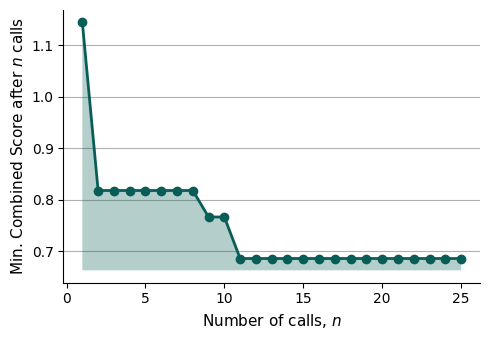

In [142]:
# plot minimum value of combined score by number of calls
fig, ax = plt.subplots(1, 1, figsize=(5,3.5))

### enumerate number of calls
x_vals = range(1, len(convergence)+1, 1)

### data
ax.plot(x_vals, convergence, linewidth=2, c=WEB_COLOR, zorder=3)
ax.scatter(x_vals, convergence, c=WEB_COLOR, zorder=3)

offset = (convergence[0]-convergence[-1])*0.05

# fill below data
ax.fill_between(
    x=x_vals, y1=convergence, y2=convergence[-1]-offset,
    color=WEB_COLOR, alpha=0.3, ec=None, zorder=2
)

### chart labels
ax.set_xlabel('Number of calls, $n$', fontsize=11)
ax.set_ylabel('Min. Combined Score after $n$ calls', fontsize=11)
#plt.title(
#    f'Epoch vs. Loss \n RNN (LSTM) Model  |  Epochs: {NUM_EPOCHS:.0f}', 
#    fontweight='bold', fontsize=11
#)

# gridlines
ax.spines[['right','top']].set_visible(False)
ax.grid(axis='y', zorder=1)

fig.tight_layout()
plt.show()

#### 6d | Dimensional Reduction of Sampled Points in Search Space

https://www.geeksforgeeks.org/machine-learning/implementing-pca-in-python-with-scikit-learn/

In [127]:
# use PCA to display all sampled points in the search space
x_iters = pd.DataFrame(bayesian_result.x_iters)

scaler = StandardScaler()
x_iters_scaled = scaler.fit_transform(x_iters)

pca = PCA(n_components=2)
x_iters_pca = pca.fit_transform(x_iters_scaled)

print(pca.explained_variance_ratio_)


[0.43779812 0.22531471]


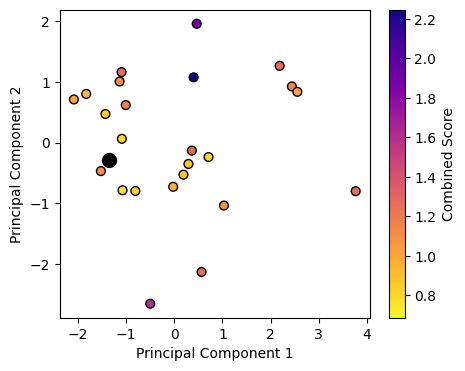

In [ ]:
# get position of minimum in 'func_vals' array
minimum_pos = np.where(bayesian_result.func_vals==min(bayesian_result.func_vals))
minimum_pos = minimum_pos[0].tolist()           # convert to list from tuple of arrays
minimum_pos


# plot PCA data
plt.figure(figsize=(5,4))

plt.scatter(
    x_iters_pca[:, 0], x_iters_pca[:, 1], 
    c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40, zorder=3
)

plt.colorbar(label="Combined Score")

#plt.plot(
#    x_iters_pca[:, 0], x_iters_pca[:, 1], c='lightgrey', zorder=2
#)

# plot thicker edge for minima
for m in minimum_pos:
    plt.scatter(
        x_iters_pca[m][0], x_iters_pca[m][1], 
        c='k', edgecolor='k', s=100, zorder=3
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [1]:
"""
fig, ax = plt.subplots(5,5, figsize=(9,9))

### ax[x,y]

ax[0,4].hist(x_iters[0], color=WEB_COLOR)
ax[1,3].hist(x_iters[1], color=WEB_COLOR)
ax[2,2].hist(x_iters[2], color=WEB_COLOR)
ax[3,1].hist(x_iters[3], color=WEB_COLOR)
ax[4,0].hist(x_iters[4], color=WEB_COLOR)

ax[0,0].scatter(x_iters[4], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[0,1].scatter(x_iters[3], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[0,2].scatter(x_iters[2], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[0,3].scatter(x_iters[1], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)

ax[1,0].scatter(x_iters[4], x_iters[1], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[1,1].scatter(x_iters[3], x_iters[1], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[1,2].scatter(x_iters[2], x_iters[1], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[1,4].scatter(x_iters[0], x_iters[1], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)

ax[2,0].scatter(x_iters[4], x_iters[2], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[2,1].scatter(x_iters[3], x_iters[2], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[2,3].scatter(x_iters[1], x_iters[2], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[2,4].scatter(x_iters[0], x_iters[2], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)

ax[3,0].scatter(x_iters[4], x_iters[3], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[3,2].scatter(x_iters[2], x_iters[3], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[3,3].scatter(x_iters[1], x_iters[3], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[3,4].scatter(x_iters[0], x_iters[3], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)

ax[4,1].scatter(x_iters[3], x_iters[4], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[4,2].scatter(x_iters[2], x_iters[4], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[4,3].scatter(x_iters[1], x_iters[4], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)
ax[4,4].scatter(x_iters[0], x_iters[4], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)

ax[4,0].set_ylabel('DROPOUT_RATE', fontsize=9)
ax[3,0].set_ylabel('NUM_LAYERS', fontsize=9)
ax[2,0].set_ylabel('NUM_EPOCHS', fontsize=9)
ax[1,0].set_ylabel('LEARNING_RATE', fontsize=9)
ax[0,0].set_ylabel('HIDDEN_DIM', fontsize=9)

ax[4,0].set_xlabel('DROPOUT_RATE', fontsize=9)
ax[4,1].set_xlabel('NUM_LAYERS', fontsize=9)
ax[4,2].set_xlabel('NUM_EPOCHS', fontsize=9)
ax[4,3].set_xlabel('LEARNING_RATE', fontsize=9)
ax[4,4].set_xlabel('HIDDEN_DIM', fontsize=9)

remove_y = ([4,0], [4,1], [4,2], [4,3], [4,4])

remove_xy = (
    [0,1], [0,2], [0,3], [0,4], [1,1], [1,2], [1,3], [1,4], 
    [2,1], [2,2], [2,3], [2,4], [3,1], [3,2], [3,3], [3,4],
    [0,0], [1,0], [2,0], [3,0],
)

ax[0,1].set_xlim(-0.3,1.3)
ax[1,1].set_xlim(-0.3,1.3)
ax[2,1].set_xlim(-0.3,1.3)
ax[3,1].set_xlim(-0.3,1.3)
ax[4,1].set_xlim(-0.3,1.3)

ax[3,0].set_ylim(-0.3,1.3)
#ax[3,1].set_ylim(-0.3,1.3)
ax[3,2].set_ylim(-0.3,1.3)
ax[3,3].set_ylim(-0.3,1.3)
ax[3,4].set_ylim(-0.3,1.3)

for vals in remove_y: ax[vals[0],vals[1]].tick_params(labelleft=False)
for vals in remove_xy: ax[vals[0],vals[1]].tick_params(labelleft=False, labelbottom=False)

#fig.tight_layout()
"""

"fig, ax = plt.subplots(5,5, figsize=(9,9))\n\n### ax[x,y]\n\nax[0,4].hist(x_iters[0], color=WEB_COLOR)\nax[1,3].hist(x_iters[1], color=WEB_COLOR)\nax[2,2].hist(x_iters[2], color=WEB_COLOR)\nax[3,1].hist(x_iters[3], color=WEB_COLOR)\nax[4,0].hist(x_iters[4], color=WEB_COLOR)\n\nax[0,0].scatter(x_iters[4], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)\nax[0,1].scatter(x_iters[3], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)\nax[0,2].scatter(x_iters[2], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)\nax[0,3].scatter(x_iters[1], x_iters[0], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)\n\nax[1,0].scatter(x_iters[4], x_iters[1], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)\nax[1,1].scatter(x_iters[3], x_iters[1], c=bayesian_result.func_vals, cmap='plasma_r', edgecolor='k', s=40)\nax[1,2].scatter(x_iters[2], x_iters[1], c=bayesian_result.func_vals, cm

### <b>7 | Repeat Best Result</b>

#### 7a | Run Experiment

In [28]:
# run experiment and save result
model, rmse_train, rmse_test, loss_by_epoch = run_experiment(
    #train, trainX, trainY_true, test, testX, testY_true,
    hidden_dim = int(bayesian_result.x[0]), 
    learning_rate = bayesian_result.x[1], 
    num_epochs = bayesian_result.x[2], 
    layer_dim = int(bayesian_result.x[3]),
    dropout_rate= bayesian_result.x[4],
)

torch.save(model.state_dict(),'logP_RNN_v3_BO.pt')

Epoch [10/1000], Loss: 1.6112
Epoch [20/1000], Loss: 1.5707
Epoch [30/1000], Loss: 1.5727
Epoch [40/1000], Loss: 1.5625
Epoch [50/1000], Loss: 1.5462
Epoch [60/1000], Loss: 1.4552
Epoch [70/1000], Loss: 1.4742
Epoch [80/1000], Loss: 1.4678
Epoch [90/1000], Loss: 1.5865
Epoch [100/1000], Loss: 1.5608
Epoch [110/1000], Loss: 1.4886
Epoch [120/1000], Loss: 1.3747
Epoch [130/1000], Loss: 1.3767
Epoch [140/1000], Loss: 1.3594
Epoch [150/1000], Loss: 1.3526
Epoch [160/1000], Loss: 1.4640
Epoch [170/1000], Loss: 1.3565
Epoch [180/1000], Loss: 1.3613
Epoch [190/1000], Loss: 1.4018
Epoch [200/1000], Loss: 1.3512
Epoch [210/1000], Loss: 1.3480
Epoch [220/1000], Loss: 1.3365
Epoch [230/1000], Loss: 1.3336
Epoch [240/1000], Loss: 1.3282
Epoch [250/1000], Loss: 1.3317
Epoch [260/1000], Loss: 1.3198
Epoch [270/1000], Loss: 1.2889
Epoch [280/1000], Loss: 1.2367
Epoch [290/1000], Loss: 1.2746
Epoch [300/1000], Loss: 1.3243
Epoch [310/1000], Loss: 1.5609
Epoch [320/1000], Loss: 1.3332
Epoch [330/1000],

In [30]:
# score experiment
score = score_experiment(rmse_train, rmse_test, 1.1)
print(f'COMPARISON SCORE: {score}')

COMPARISON SCORE: 0.6528530597242058


#### 7b | Visualise Loss per Epoch

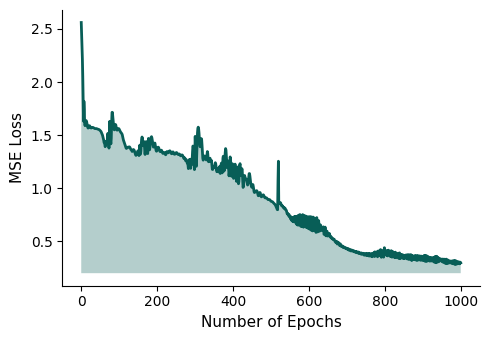

In [31]:
# plot loss values per epoch
fig, ax = plt.subplots(1, 1, figsize=(5,3.5))

### enumerate epochs
x_vals = range(0, len(loss_by_epoch), 1)

### data
ax.plot(x_vals, loss_by_epoch, linewidth=2, c=WEB_COLOR)

# fill below data
ax.fill_between(
    x=x_vals, y1=loss_by_epoch, y2=0.2,
    color=WEB_COLOR, alpha=0.3, ec=None,
)

### chart labels
ax.set_xlabel('Number of Epochs', fontsize=11)
ax.set_ylabel('MSE Loss', fontsize=11)
#plt.title(
#    f'Epoch vs. Loss \n RNN (LSTM) Model  |  Epochs: {NUM_EPOCHS:.0f}', 
#    fontweight='bold', fontsize=11
#)

# gridlines
ax.spines[['right','top']].set_visible(False)

fig.tight_layout()
plt.show()

#### 7c | Visualise RMSE between Predicted and True Datasets

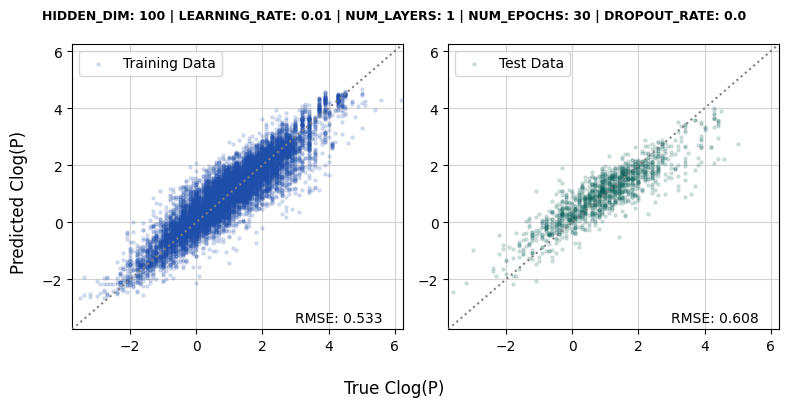

In [32]:
# plot true vs. predicted log(P) values for training and testing data 
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].grid(True, color='lightgrey', zorder=1)
ax[1].grid(True, color='lightgrey', zorder=1)

### data
ax[0].scatter(train['ClogP'], train['ClogP (Predicted)'], c='#1E4DAA', s=5, alpha=0.15, label='Training Data', zorder=2)
ax[1].scatter(test['ClogP'], test['ClogP (Predicted)'], c=WEB_COLOR, s=5, alpha=0.15, label='Test Data', zorder=2)

### ideal fit
ax[0].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":", zorder=3)
ax[1].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":", zorder=3)

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[0].set_ylim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)
ax[1].set_ylim(-3.75, 6.25)

### legends
ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)

### chart labels
fig.supxlabel('True Clog(P)')
fig.supylabel('Predicted Clog(P)')
fig.suptitle(
    f'HIDDEN_DIM: {HIDDEN_DIM} | LEARNING_RATE: {LEARNING_RATE} | NUM_LAYERS: {NUM_LAYERS} | NUM_EPOCHS: {NUM_EPOCHS} | DROPOUT_RATE: {DROPOUT_RATE}', 
    fontsize=9, fontweight='bold', 
)

### annotate with RMSEs
ax[0].annotate(f'RMSE: {rmse_train:.3f}', xy=(3,-3.5), fontsize=10)
ax[1].annotate(f'RMSE: {rmse_test:.3f}', xy=(3,-3.5), fontsize=10)

fig.tight_layout()
plt.show()

#### 7d | Visualise Molecules with Largest and Smallest Errors

Size of SMILES_list: 18


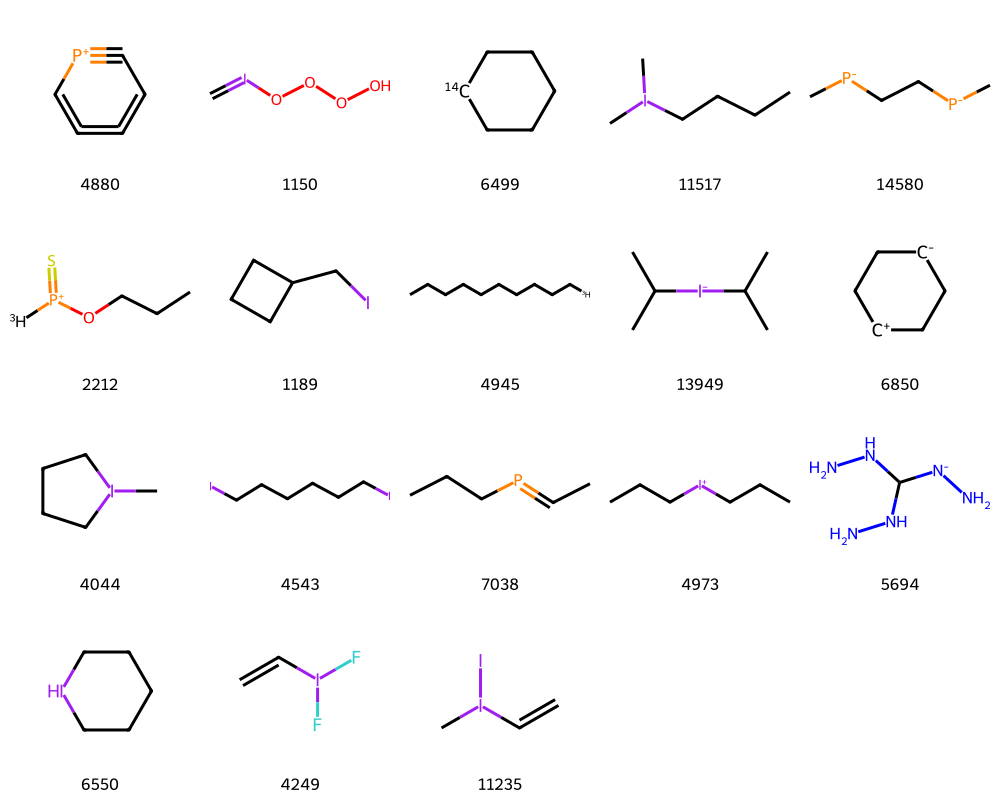

In [115]:
# add absolute error to the 'test' DataFrame
test['Absolute Error'] = abs(test['Error'])

# set cutoff to print all molecules above
ABSOLUTE_ERROR_CUTOFF = 1.8

# create list of SMILES above 
SMILES_list = test[test['Absolute Error']>=ABSOLUTE_ERROR_CUTOFF]['SMILES'].values.tolist()
print(f'Size of SMILES_list: {len(SMILES_list)}')

# get 'test' DataFrame indices corresponding to each SMILES and convert to strings
legends_list = test.index[test['Absolute Error']>=ABSOLUTE_ERROR_CUTOFF].tolist()
legends_list = [str(x) for x in legends_list]

# create Mol objects from SMILES
ms = [Chem.MolFromSmiles(smi) for smi in SMILES_list]   ### 'SMILES_list' sliced to visualise selected values only

# visualise Mol objects
opts = Draw.MolDrawOptions()
opts.drawMolsSameScale = False     # undoes the default behaviour of scaling everything to fit the largest molecule
opts.fixedBondLength = 30          # sets an upper limit for the max bond length
opts.bondLineWidth = 3             # sets a slightly thicker bond width (default is 2)
img = Draw.MolsToGridImage(
    ms, molsPerRow=5, subImgSize=(200,200), legends=legends_list, drawOptions=opts
)
display(img)

Size of SMILES_list: 19


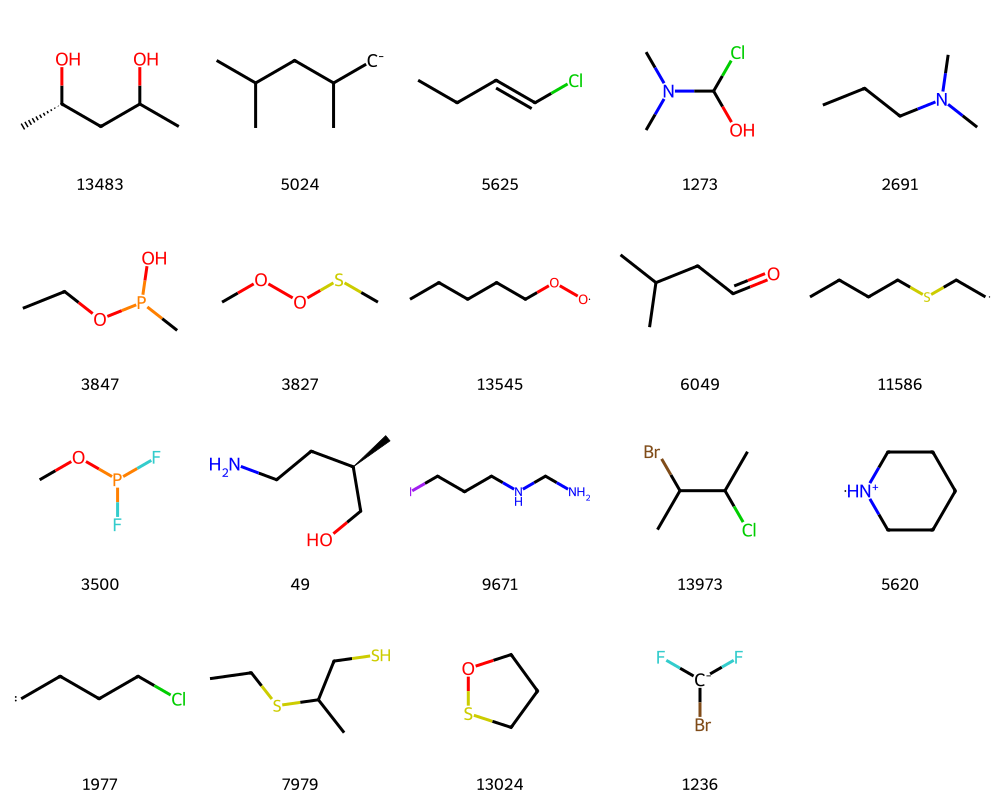

In [116]:
# add absolute error to the 'test' DataFrame
test['Absolute Error'] = abs(test['Error'])

# set cutoff to print all molecules above
ABSOLUTE_ERROR_CUTOFF = 0.01

# create list of SMILES above 
SMILES_list = test[test['Absolute Error']<=ABSOLUTE_ERROR_CUTOFF]['SMILES'].values.tolist()
print(f'Size of SMILES_list: {len(SMILES_list)}')

# get 'test' DataFrame indices corresponding to each SMILES and convert to strings
legends_list = test.index[test['Absolute Error']<=ABSOLUTE_ERROR_CUTOFF].tolist()
legends_list = [str(x) for x in legends_list]

# create Mol objects from SMILES
ms = [Chem.MolFromSmiles(smi) for smi in SMILES_list]   ### 'SMILES_list' sliced to visualise selected values only

# visualise Mol objects
opts = Draw.MolDrawOptions()
opts.drawMolsSameScale = False     # undoes the default behaviour of scaling everything to fit the largest molecule
opts.fixedBondLength = 30          # sets an upper limit for the max bond length
opts.bondLineWidth = 3             # sets a slightly thicker bond width (default is 2)
img = Draw.MolsToGridImage(
    ms, molsPerRow=5, subImgSize=(200,200), legends=legends_list, drawOptions=opts
)
display(img)

In [117]:
test[test.index==6850]

,SMILES,ClogP,Tokenize,Tokenized Length,ClogP (Predicted),Error,Absolute Error
6850,C1C[CH+]CC[CH-]1,3.4,"[tensor(1), tensor(4), tensor(17), tensor(4), ...",18,1.488867,-1.911133,1.911133
